# Logistic Regression for Breast-Cancer Classification

This notebook demonstrates a leakage-free classification pipeline, compares regularization strengths, and evaluates the final model with more than accuracy alone.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## 1. Data and preprocessing

The split is stratified to preserve class balance. Scaling is fitted only on the training set through the pipeline, improving optimization and making coefficient comparisons meaningful.


In [2]:
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    test_size=0.25,
    stratify=cancer.target,
    random_state=42,
)

def build_model(C):
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C, max_iter=2000, random_state=42),
    )


## 2. Effect of regularization

Smaller `C` means stronger L2 regularization; larger `C` allows larger coefficients and a closer fit to training data.


In [3]:
C_values = [0.01, 1.0, 100.0]
models = {}

for C in C_values:
    model = build_model(C)
    model.fit(X_train, y_train)
    models[C] = model
    print(
        f"C={C:g}: training accuracy={model.score(X_train, y_train):.3f}, "
        f"test accuracy={model.score(X_test, y_test):.3f}"
    )


C=0.01: training accuracy=0.958, test accuracy=0.937
C=1: training accuracy=0.988, test accuracy=0.986
C=100: training accuracy=0.998, test accuracy=0.944


## 3. Standardized coefficients

Because all features are standardized inside each pipeline, coefficient magnitudes can be compared across features. The labels below exactly match the fitted `C` values.


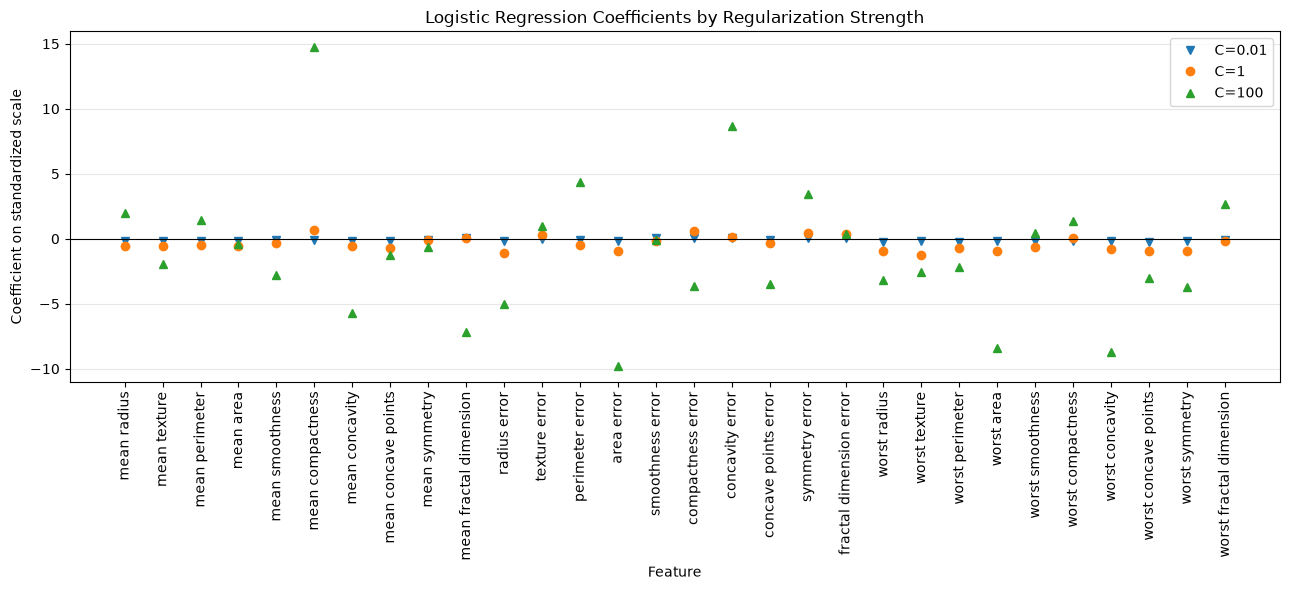

In [4]:
plt.figure(figsize=(13, 6))
for C, marker in zip(C_values, ["v", "o", "^"]):
    coefficients = models[C].named_steps["logisticregression"].coef_[0]
    plt.plot(coefficients, marker=marker, linestyle="none", label=f"C={C:g}")

plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(range(len(cancer.feature_names)), cancer.feature_names, rotation=90)
plt.xlabel("Feature")
plt.ylabel("Coefficient on standardized scale")
plt.title("Logistic Regression Coefficients by Regularization Strength")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Final evaluation

The `C=1` model is used as a clear baseline. Precision, recall, F1-score, and the confusion matrix show error types that accuracy alone can hide.


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



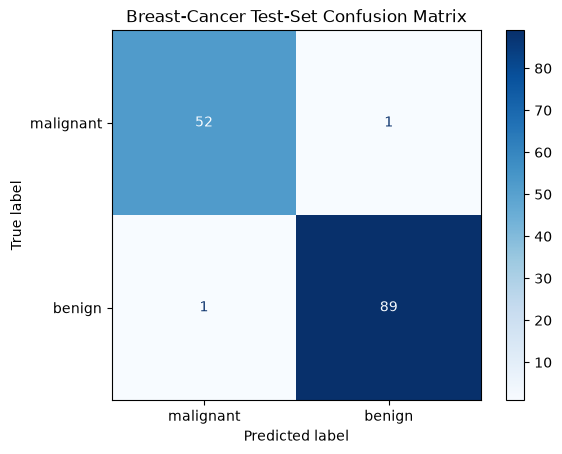

In [5]:
final_model = models[1.0]
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=cancer.target_names))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=cancer.target_names,
    cmap="Blues",
)
plt.title("Breast-Cancer Test-Set Confusion Matrix")
plt.show()
